# 7B Block-Design Analysis

**Data:** each run consists of 20 emotional prompts followed by 20 neutral prompts (or vice versa), separated by a full node reboot.

**Pipeline:**
1. Clustering on **raw** features — single-feature sweep, majority filter, MWU with Bonferroni.
2. Check if `elapsed_ms` differs significantly between conditions. Residualise only if it does.
3. Clustering on **residualised** features (if applicable).
4. **Null test:** random label assignment within a single condition, checked across 20 repeats. Accuracy should hover around 50%.

**Note on residualisation:** `prompt_index` is NOT used as a covariate — in the block design, emotional and neutral trials occupy different block positions, so prompt_index is fully correlated with condition label and cannot serve as a confound control.

## §1 — Imports and configuration

In [155]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR   = BASE_DIR / 'data' / 'longer70b'
RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = ['219a', '219b', '219c', '220a', '233a', '233c','187a', '200a']

# ── L1 indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    #'hat_TLB',
    #'tlb:tlb_flush',
    'core_power.throttle',
]
# ── Analysis config ────────────────────────────────────────────────────────────
MAJORITY_THRESHOLD = 0.75
N_INIT             = 50
RAND_SEED          = 42
N_NULL_REPEATS     = 20

print('Configuration OK')
print(f'  Runs              : {RUNS}')
print(f'  Majority threshold: {MAJORITY_THRESHOLD:.0%}')
print(f'  Null repeats      : {N_NULL_REPEATS}')


Configuration OK
  Runs              : ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
  Majority threshold: 75%
  Null repeats      : 20


## §2 — Load data

In [156]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')

Loaded 8 runs: ['219a', '219b', '219c', '220a', '233a', '233c', '187a', '200a']
  Total trials : 320
  Emotional    : 160
  Neutral      : 160


## §3 — Select L1 features

In [157]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[["core_power.throttle__slope", "core_power.throttle__variance", "core_power.throttle__spectral_entropy", "core_power.throttle__mean_rate", "core_power.throttle__lz_complexity"]].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')
print(f'Features: {list(X_l1.columns)}')

L1 features available: 5
Features: ['core_power.throttle__slope', 'core_power.throttle__variance', 'core_power.throttle__spectral_entropy', 'core_power.throttle__mean_rate', 'core_power.throttle__lz_complexity']


## §4 — Helper functions

In [158]:
def kmeans_acc_ari(X, y, n_init=N_INIT, seed=RAND_SEED):
    """K-means (k=2) with majority-vote alignment. Returns (accuracy, ARI)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


def single_feature_sweep(X_feat_df, df, label_col='label'):
    """Single-feature sweep with per-run direction analysis and majority filter."""
    y_true = df[label_col].values
    runs_unique = df['run'].unique()
    records = []
    for col in X_feat_df.columns:
        acc, ari = kmeans_acc_ari(X_feat_df[[col]].values, y_true)
        e_mean = X_feat_df.loc[df['condition'] == 'emotional', col].mean()
        n_mean = X_feat_df.loc[df['condition'] == 'neutral',   col].mean()
        direction = '↑E' if e_mean > n_mean else '↑N'
        
        run_dirs = []
        for run in runs_unique:
            mask_run = df['run'] == run
            e_run = X_feat_df.loc[mask_run & (df['condition'] == 'emotional'), col].mean()
            n_run = X_feat_df.loc[mask_run & (df['condition'] == 'neutral'),   col].mean()
            if not (np.isnan(e_run) or np.isnan(n_run)):
                run_dirs.append('↑E' if e_run > n_run else '↑N')
        
        n_majority = sum(1 for d in run_dirs if d == direction)
        n_valid    = len(run_dirs)
        maj_frac   = n_majority / n_valid if n_valid > 0 else 0.0
        
        records.append({
            'feature':       col,
            'accuracy':      acc,
            'ari':           ari,
            'direction':     direction,
            'runs_majority': f'{n_majority}/{n_valid}',
            'majority_frac': maj_frac,
        })
    return pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)


def mwu_bonferroni(X_feat_df, df, features):
    """Mann-Whitney U with Bonferroni correction for a list of features."""
    if not len(features):
        return pd.DataFrame()
    records = []
    for feat in features:
        e = X_feat_df.loc[df.condition == 'emotional', feat].dropna()
        n = X_feat_df.loc[df.condition == 'neutral',   feat].dropna()
        u, p_raw = mannwhitneyu(e, n, alternative='two-sided')
        p_corr = min(p_raw * len(features), 1.0)
        records.append({
            'feature':     feat,
            'U':           u,
            'p_raw':       p_raw,
            'p_corrected': p_corr,
            'significant': 'YES' if p_corr < 0.05 else 'NO',
        })
    return pd.DataFrame(records)

print('Helpers defined.')

Helpers defined.


## §5 — Raw clustering (no residualisation)

In [159]:
print('=' * 70)
print('RAW CLUSTERING (no residualisation)')
print('=' * 70)

sf_raw = single_feature_sweep(X_l1, df_all)

print('\nAll features (sorted by accuracy):')
print(sf_raw[['feature', 'accuracy', 'ari', 'direction', 'runs_majority', 'majority_frac']].to_string(index=False))

sf_raw_filtered = sf_raw[sf_raw['majority_frac'] >= MAJORITY_THRESHOLD].reset_index(drop=True)
print(f'\nFeatures passing ≥{MAJORITY_THRESHOLD:.0%} majority: {len(sf_raw_filtered)}')
if len(sf_raw_filtered):
    print(sf_raw_filtered[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))

print('\nMann-Whitney U (Bonferroni-corrected across majority-passing features):')
mwu_raw = mwu_bonferroni(X_l1, df_all, sf_raw_filtered['feature'].tolist())
if not mwu_raw.empty:
    print(mwu_raw.to_string(index=False))
else:
    print('  No features passed majority threshold.')

RAW CLUSTERING (no residualisation)

All features (sorted by accuracy):
                              feature  accuracy      ari direction runs_majority  majority_frac
           core_power.throttle__slope  0.609375 0.044970        ↑N           7/8          0.875
        core_power.throttle__variance  0.596875 0.034675        ↑N           8/8          1.000
core_power.throttle__spectral_entropy  0.596875 0.034522        ↑E           7/8          0.875
   core_power.throttle__lz_complexity  0.590625 0.030592        ↑E           6/8          0.750
       core_power.throttle__mean_rate  0.556250 0.010816        ↑N           4/8          0.500

Features passing ≥75% majority: 4
                              feature  accuracy      ari direction runs_majority
           core_power.throttle__slope  0.609375 0.044970        ↑N           7/8
        core_power.throttle__variance  0.596875 0.034675        ↑N           8/8
core_power.throttle__spectral_entropy  0.596875 0.034522        ↑E        

## §8 — Null test: random labels within a single condition

Clustering on emotional-only trials (or neutral-only trials) with randomly assigned pseudo-labels. Accuracy should hover around 50% and ARI around 0, confirming there is no spurious structure being picked up.

In [160]:
# Pick the best raw feature to test for spurious structure
NULL_FEATURE = sf_raw.iloc[0]['feature']
print(f'Null test feature: {NULL_FEATURE}')
print(f'(Testing whether clustering picks up structure with random labels)\n')

rng = np.random.default_rng(RAND_SEED)

for cond in ['emotional', 'neutral']:
    sub = df_all[df_all.condition == cond].copy().reset_index(drop=True)
    n_total = len(sub)
    X_sub = sub[[NULL_FEATURE]].fillna(sub[[NULL_FEATURE]].median()).values
    
    accs, aris = [], []
    for _ in range(N_NULL_REPEATS):
        # Assign exactly 50/50 random pseudo-labels
        pseudo = np.zeros(n_total, dtype=int)
        pseudo[:n_total // 2] = 1
        rng.shuffle(pseudo)
        
        if len(np.unique(pseudo)) < 2:
            continue
        
        acc, ari = kmeans_acc_ari(X_sub, pseudo)
        accs.append(acc)
        aris.append(ari)
    
    print(f'{cond:10s}  n={n_total:4d}  '
          f'mean_acc={np.mean(accs):.4f} ± {np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f} ± {np.std(aris):.4f}')

print(f'\nExpected: accuracy ≈ 0.50, ARI ≈ 0.00')
print(f'Repeats per condition: {N_NULL_REPEATS}')

Null test feature: core_power.throttle__slope
(Testing whether clustering picks up structure with random labels)

emotional   n= 160  mean_acc=0.5306 ± 0.0187  mean_ARI=-0.0008 ± 0.0056
neutral     n= 160  mean_acc=0.5313 ± 0.0194  mean_ARI=-0.0002 ± 0.0054

Expected: accuracy ≈ 0.50, ARI ≈ 0.00
Repeats per condition: 20


## §9 — Summary

In [161]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)
print(f'Runs loaded          : {len(runs_loaded)}')
print(f'Total trials         : {len(df_all)}')
print(f'Features tested      : {X_l1.shape[1]}')
print()
print(f'Raw clustering — best feature      : {sf_raw.iloc[0].feature}')
print(f'                  accuracy         : {sf_raw.iloc[0].accuracy:.4f}')
print(f'                  ARI              : {sf_raw.iloc[0].ari:.4f}')
print(f'                  direction        : {sf_raw.iloc[0].direction} ({sf_raw.iloc[0].runs_majority})')
print()
print(f'elapsed_ms condition difference: p={p_ms:.4f}')


SUMMARY
Runs loaded          : 8
Total trials         : 320
Features tested      : 5

Raw clustering — best feature      : core_power.throttle__slope
                  accuracy         : 0.6094
                  ARI              : 0.0450
                  direction        : ↑N (7/8)

elapsed_ms condition difference: p=0.1726


# ROB SWEEP

In [162]:
# ── Robustness sweep on the best raw feature ──────────────────────────────────
# For each subset size x, draw x/2 emotional + x/2 neutral prompt_indices,
# pool across all runs, and run clustering. Repeat N_REPEATS times.

SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20

BEST_FEATURE = sf_raw.iloc[0]['feature']
print(f'Robustness sweep feature: {BEST_FEATURE}\n')

emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')
print()

rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        X_sub = X_l1.loc[mask, BEST_FEATURE].values.reshape(-1, 1)
        y_sub = df_all.loc[mask, 'label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)

Robustness sweep feature: core_power.throttle__slope

Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Neutral prompt indices   (20):   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

  x=22  total= 176  mean_acc=0.6020  ±0.0145  mean_ARI=0.0372
  x=24  total= 192  mean_acc=0.6052  ±0.0190  mean_ARI=0.0409
  x=26  total= 208  mean_acc=0.6075  ±0.0160  mean_ARI=0.0428
  x=28  total= 224  mean_acc=0.6076  ±0.0137  mean_ARI=0.0429
  x=30  total= 240  mean_acc=0.6062  ±0.0138  mean_ARI=0.0421
  x=32  total= 256  mean_acc=

In [164]:
# Features to sweep for the appendix table
remaining_features = [
    'core_power.throttle__variance',
    'core_power.throttle__spectral_entropy',
    'core_power.throttle__lz_complexity'
]

SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
rng = np.random.default_rng(RAND_SEED)

emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print("Robustness Sweep Summary for Table")
print("-" * 50)

for feature in remaining_features:
    print(f"Sweeping feature: {feature}")
    feature_mean_accs = []
    feature_std_accs = []
    
    for x in SUBSET_SIZES:
        half = x // 2
        accs = []
        
        for _ in range(N_REPEATS):
            e_sel = rng.choice(emotional_prompts, size=half, replace=False)
            n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

            mask = (
                ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
                ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
            )
            X_sub = X_l1.loc[mask, feature].values.reshape(-1, 1)
            y_sub = df_all.loc[mask, 'label'].values

            if len(np.unique(y_sub)) < 2:
                continue

            acc, _ = kmeans_acc_ari(X_sub, y_sub)  # Ignoring ARI for the table
            accs.append(acc)

        feature_mean_accs.append(np.mean(accs))
        feature_std_accs.append(np.std(accs))

    # Extract metrics for the LaTeX table
    min_acc = min(feature_mean_accs)
    max_acc = max(feature_mean_accs)
    min_sd = min(feature_std_accs)
    max_sd = max(feature_std_accs)
    
    print(f"  Acc. range : {min_acc:.3f} - {max_acc:.3f}")
    print(f"  Max SD     : {max_sd:.3f}")
    print(f"  Min SD     : {min_sd:.3f}\n")

Robustness Sweep Summary for Table
--------------------------------------------------
Sweeping feature: core_power.throttle__variance
  Acc. range : 0.587 - 0.600
  Max SD     : 0.027
  Min SD     : 0.000

Sweeping feature: core_power.throttle__spectral_entropy
  Acc. range : 0.589 - 0.599
  Max SD     : 0.027
  Min SD     : 0.000

Sweeping feature: core_power.throttle__lz_complexity
  Acc. range : 0.576 - 0.592
  Max SD     : 0.021
  Min SD     : 0.000



<function matplotlib.pyplot.show(close=None, block=None)>

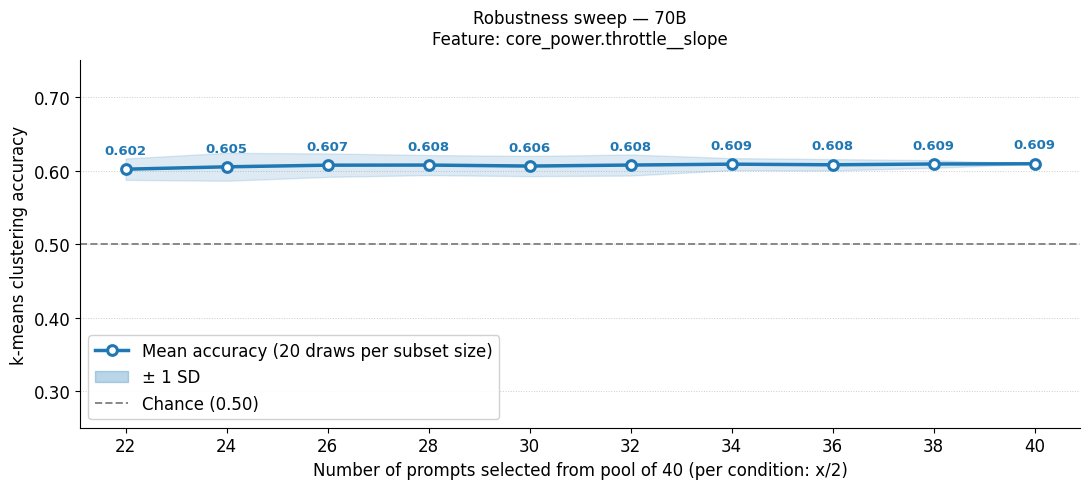

In [163]:
COLOR      = '#1f77b4'  # Strong Academic Blue
COLOR_BAND = '#1f77b4'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(11, 5))

# Shaded band first
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.15, color=COLOR_BAND, zorder=1)

# Main line
ax.plot(xs, mean, marker='o', lw=2.5, color=COLOR,
        markersize=7, markerfacecolor='white', markeredgewidth=2.2,
        zorder=3, label='Mean accuracy (20 draws per subset size)')

# SD band label for legend
import matplotlib.patches as mpatches
band_patch = mpatches.Patch(color=COLOR_BAND, alpha=0.3, label='± 1 SD')

# Chance line
ax.axhline(0.5, color='#888888', lw=1.4, ls='--', zorder=2, label='Chance (0.50)')

# Accuracy labels above points
for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', xy=(xi, mi),
                textcoords='offset points', xytext=(0, 11),
                ha='center', fontsize=9.5, color=COLOR, fontweight='bold')

# Axes
ax.set_xlabel('Number of prompts selected from pool of 40 (per condition: x/2)', fontsize=12)
ax.set_ylabel('k-means clustering accuracy', fontsize=12)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=12)
ax.set_ylim(0.25, 0.75)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# Grid
ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#cccccc', zorder=0)
ax.set_axisbelow(True)

# Title
ax.set_title(
    f'Robustness sweep — 70B\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=12, pad=12
)

ax.legend(handles=[ax.lines[0], band_patch, ax.lines[1]],
          fontsize=12, framealpha=0.9, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show